<a href="https://colab.research.google.com/github/irajamuller/shor_code/blob/main/shor_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalação e Carregamento de bibliotecas

In [1]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00


In [2]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

# Diagrama utilizado na implementação do Circuito Quântico
### Fonte: https://pennylane.ai/challenges/a_shor_thing

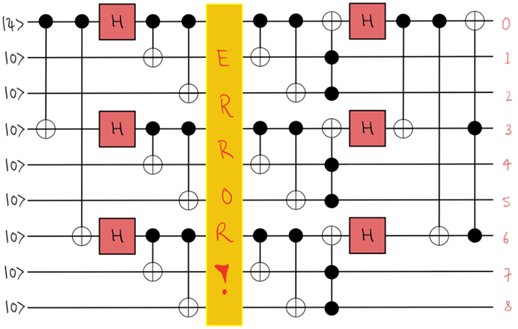

# Funções para a Codificação de Shor

In [22]:
def encode(qc, d):
  qc.barrier(label='Encode')
  # Phase-flip layer
  qc.cx(d[0], d[3])
  qc.cx(d[0], d[6])
  qc.h(d[0])
  qc.h(d[3])
  qc.h(d[6])

  # Bit-flip layers (3 blocos)
  for i in [0, 3, 6]:
    qc.cx(d[i], d[i + 1])
    qc.cx(d[i], d[i + 2])

def inject_error(qc, d, errors):
  qc.barrier(label="Error")
  if not errors:
      return
  for qubit, etype in errors:
      if etype in ('X', 'Y'):
          qc.x(d[qubit])
      if etype in ('Z', 'Y'):
          qc.z(d[qubit])

def measure_syndrome_x(qc, d, a, s0, s1, s2):
  qc.barrier(label='Syndrome X')

  # Reset
  for i in range(6):
      qc.reset(a[i])

  # Bloco 1
  qc.cx(d[0], a[0]); qc.cx(d[1], a[0])   # paridade d0⊕d1
  qc.cx(d[1], a[1]); qc.cx(d[2], a[1])   # paridade d1⊕d2
  # Bloco 2
  qc.cx(d[3], a[2]); qc.cx(d[4], a[2])   # paridade d3⊕d4
  qc.cx(d[4], a[3]); qc.cx(d[5], a[3])   # paridade d4⊕d5
  # Bloco 3
  qc.cx(d[6], a[4]); qc.cx(d[7], a[4])   # paridade d6⊕d7
  qc.cx(d[7], a[5]); qc.cx(d[8], a[5])   # paridade d7⊕d8

  qc.measure(a[0], s0[0]); qc.measure(a[1], s0[1])
  qc.measure(a[2], s1[0]); qc.measure(a[3], s1[1])
  qc.measure(a[4], s2[0]); qc.measure(a[5], s2[1])

def measure_syndrome_z(qc, d, a, sz):
  qc.barrier(label='Syndrome Z')
  qc.reset(a[0]); qc.reset(a[1])

  # Paridade de fase: bloco 0 (d0,d1,d2) vs bloco 1 (d3,d4,d5)
  qc.h(a[0])
  for i in [0, 1, 2]:        # todos do bloco 0
      qc.cx(a[0], d[i])
  for i in [3, 4, 5]:        # todos do bloco 1
      qc.cx(a[0], d[i])
  qc.h(a[0])

  # Paridade de fase: bloco 1 (d3,d4,d5) vs bloco 2 (d6,d7,d8)
  qc.h(a[1])
  for i in [3, 4, 5]:        # todos do bloco 1
      qc.cx(a[1], d[i])
  for i in [6, 7, 8]:        # todos do bloco 2
      qc.cx(a[1], d[i])
  qc.h(a[1])

  qc.measure(a[0], sz[0])
  qc.measure(a[1], sz[1])
      # # Reset
  # qc.reset(a[0])
  # qc.reset(a[1])

  # qc.h(a[0])
  # qc.cx(d[0], a[0]); qc.cx(d[3], a[0])
  # qc.h(a[0])

  # qc.h(a[1])
  # qc.cx(d[3], a[1]); qc.cx(d[6], a[1])
  # qc.h(a[1])

  # qc.measure(a[0], sz[0])
  # qc.measure(a[1], sz[1])

def correct_x(qc, d, s0, s1, s2):
  qc.barrier(label='Correction X')
  # Bloco 0
  with qc.if_test((s0, 0b01)): qc.x(d[0])
  with qc.if_test((s0, 0b11)): qc.x(d[1])
  with qc.if_test((s0, 0b10)): qc.x(d[2])
  # Bloco 1
  with qc.if_test((s1, 0b01)): qc.x(d[3])
  with qc.if_test((s1, 0b11)): qc.x(d[4])
  with qc.if_test((s1, 0b10)): qc.x(d[5])
  # Bloco 2
  with qc.if_test((s2, 0b01)): qc.x(d[6])
  with qc.if_test((s2, 0b11)): qc.x(d[7])
  with qc.if_test((s2, 0b10)): qc.x(d[8])

def correct_z(qc, d, sz):
  qc.barrier(label='Correction Z')

  with qc.if_test((sz, 0b01)): qc.z(d[0])  # bloco 0
  with qc.if_test((sz, 0b11)): qc.z(d[3])  # bloco 1
  with qc.if_test((sz, 0b10)): qc.z(d[6])  # bloco 2

def decode(qc, d):
  qc.barrier(label='Decode')
  for i in [0, 3, 6]:
    qc.cx(d[i], d[i + 1])              # desfaz cópia 1
    qc.cx(d[i], d[i + 2])              # desfaz cópia 2

  # Inverte Hadamard
  qc.h(d[0]); qc.h(d[3]); qc.h(d[6])

  qc.cx(d[0], d[3])
  qc.cx(d[0], d[6])
  qc.ccx(d[3], d[6], d[0])   # Toffoli: voto majoritário phase-flip

def create_circuit(psi, errors):
  q_codes = QuantumRegister(9, 'code')

  q_ancilla_x = QuantumRegister(6, 'ancilla_x')
  q_ancilla_z = QuantumRegister(2, 'ancilla_z')

  c_syndromes0 = ClassicalRegister(2, name='syndrom b0')   # síndrome bloco 0
  c_syndromes1 = ClassicalRegister(2, name='syndrom b1')   # síndrome bloco 1
  c_syndromes2 = ClassicalRegister(2, name='syndrom b2')   # síndrome bloco 2
  c_syndromes_z = ClassicalRegister(2, name='syndrom z')   # síndrome Z

  logical_bit = ClassicalRegister(1, 'logical bit')

  qc = QuantumCircuit(q_codes, q_ancilla_x, q_ancilla_z, c_syndromes0, c_syndromes1, c_syndromes2, c_syndromes_z, logical_bit)
  qc.barrier(label="Initial state")

  # Troca estado inicial de |0> para |1>
  if psi != '0': qc.x(q_codes[0])

  # Encode
  encode(qc, q_codes)

  # Inject Error
  inject_error(qc, q_codes, errors)

  # Measure, and correction X errors
  measure_syndrome_x(qc, q_codes, q_ancilla_x, c_syndromes0, c_syndromes1, c_syndromes2)
  measure_syndrome_z(qc, q_codes, q_ancilla_z, c_syndromes_z)

  # Measure, and correction Z errors
  correct_x(qc, q_codes, c_syndromes0, c_syndromes1, c_syndromes2)
  correct_z(qc, q_codes, c_syndromes_z)

  # Decode
  decode(qc, q_codes)

  qc.barrier(label='fim')
  qc.measure(q_codes[0], logical_bit[0])

  return qc

# Criação do Circuito Quântico (somente para testes)

In [23]:
# Inicializa circuito com estado psi para enviar
#qc = create_circuit('0', [(0, 'Z'), (0, 'X'), (3, 'X'), (6, 'X')])
qc = create_circuit('0', [(0, 'Z')])

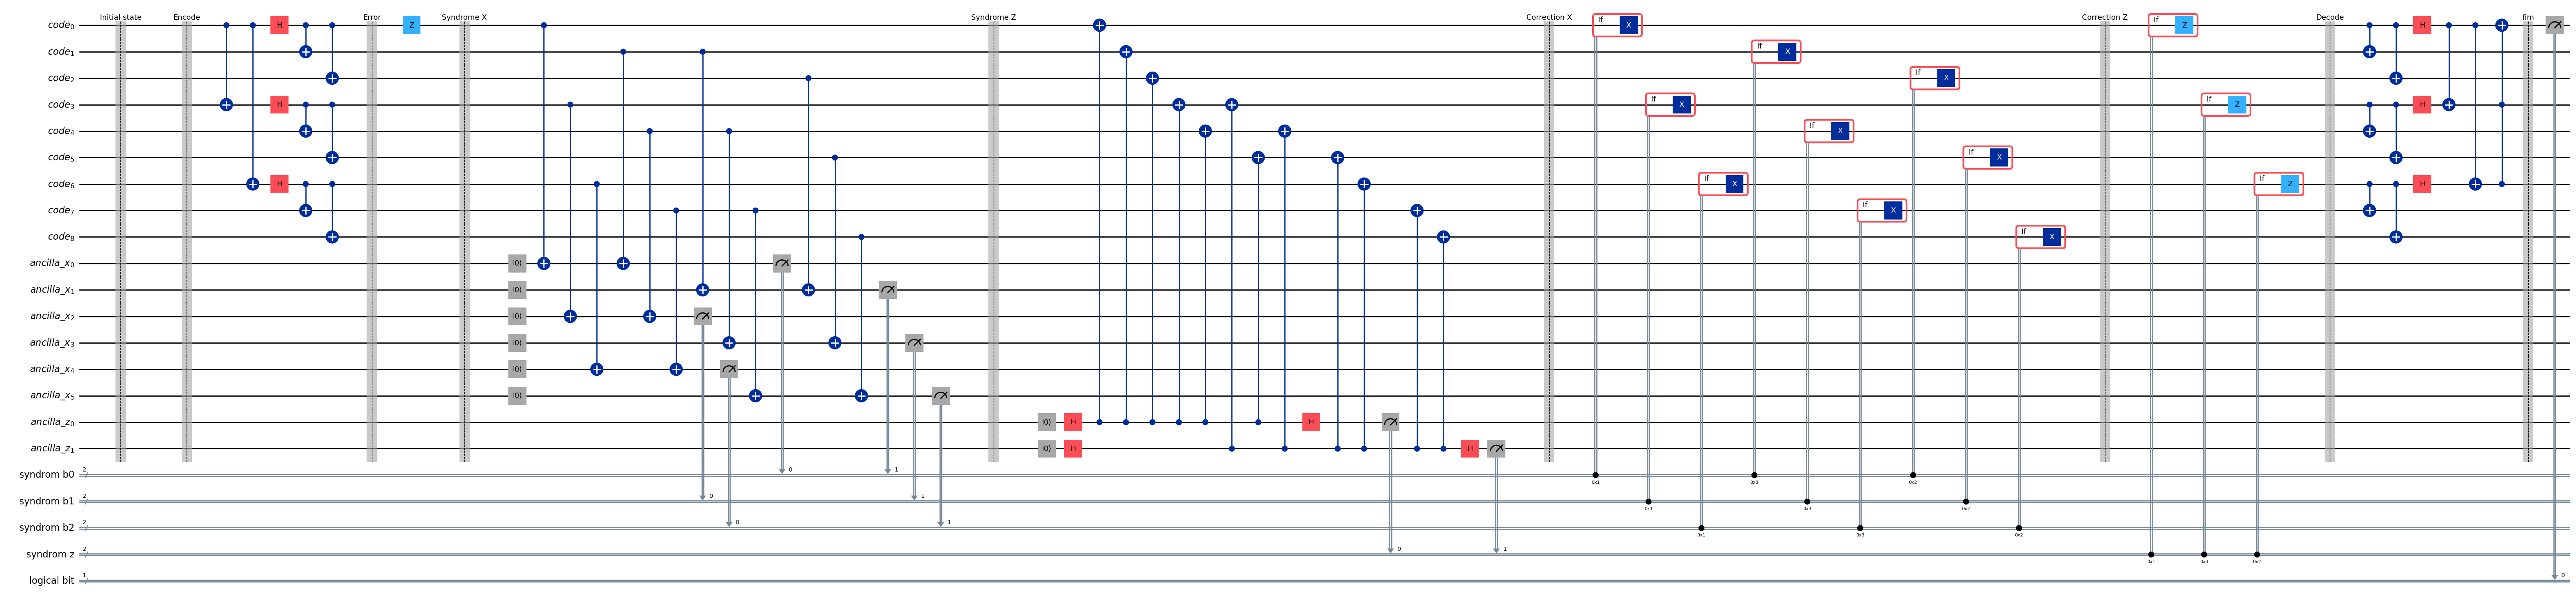

In [24]:
qc.draw('mpl', fold=-1)

# Estado Antes da Medição (somente para testes)

In [ ]:
qc.remove_final_measurements()
backend = Aer.get_backend('statevector_simulator')
result = backend.run(qc).result()
final_state = result.get_statevector()

# 4. Ver as amplitudes
final_state.draw('latex')

<IPython.core.display.Latex object>

# Execução do Algoritmo (somente para testes)

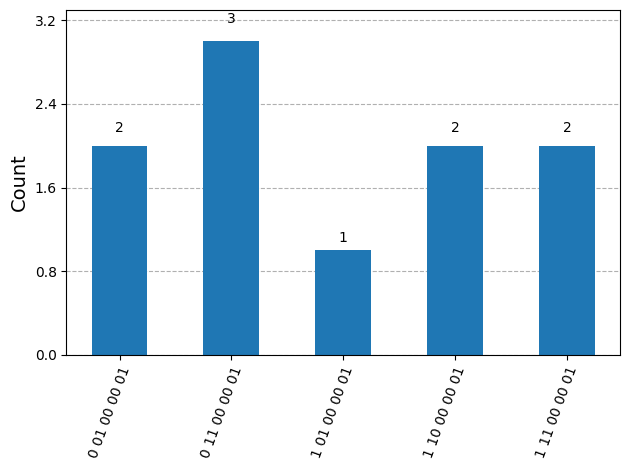

In [ ]:
backend = AerSimulator(method='statevector')
#AerSimulator(method="automatic")

result = backend.run(qc, shots=10).result()
counts = result.get_counts()

plot_histogram(counts)

# Análise dos Erros

In [30]:
def analyze_errors(errors):
  if not errors:
      return {'correctable': True, 'reason': 'sem erros',
              'block_x_count': {}, 'z_count': 0}

  # Colapsa X+Z no mesmo qubit → Y (representação canônica)
  from collections import defaultdict
  qubit_types: dict[int, set] = defaultdict(set)
  for qubit, etype in errors:
      for component in ('X', 'Z') if etype == 'Y' else [etype]:
          qubit_types[qubit].add(component)

  # Reconstrói lista canônica: nunca haverá duplicatas agora
  canonical = []
  for qubit, components in qubit_types.items():
      if components == {'X', 'Z'}:
          canonical.append((qubit, 'Y'))
      elif components == {'X'}:
          canonical.append((qubit, 'X'))
      elif components == {'Z'}:
          canonical.append((qubit, 'Z'))
      else:
          # X+X ou Z+Z se cancelam — erro nulo neste qubit
          pass  # não adiciona: efeito líquido é identidade

  # A partir daqui, usa `canonical` no lugar de `errors`
  block_x: dict[int, int] = {0: 0, 1: 0, 2: 0}
  block_z: set[int] = set()

  for qubit, etype in canonical:
      block = qubit // 3
      if etype in ('X', 'Y'):
          block_x[block] += 1
      if etype in ('Z', 'Y'):
          block_z.add(block)

  # Regra 1: no máximo 1 erro X por bloco
  for b, cnt in block_x.items():
      if cnt > 1:
          return {
              'correctable': False,
              'reason': (f'{cnt} erros X no bloco {b} '
                          f'[d{b*3}..d{b*3+2}] — síndrome ambígua'),
              'block_x_count': block_x,
              'z_count': len(block_z)
          }

  # Regra 2: no máximo 1 bloco com erro Z
  if len(block_z) > 1:
      return {
          'correctable': False,
          'reason': (f'erros Z em {len(block_z)} blocos diferentes '
                      f'{sorted(block_z)} — voto majoritário enganado'),
          'block_x_count': block_x,
          'z_count': len(block_z)
      }

  return {
      'correctable': True,
      'reason': 'dentro da capacidade do código',
      'block_x_count': block_x,
      'z_count': len(block_z)
  }

# Análise de execução do experimento

In [31]:
def run_experiment(initial_state='0', errors=None, shots=100):
    errors = errors or []
    analysis = analyze_errors(errors)
    qc = create_circuit(initial_state, errors)

    backend = AerSimulator(method='statevector')
    qc_t = transpile(qc, backend=backend)

    result = backend.run(qc_t, shots=shots).result()
    counts = result.get_counts()
    print("  COUNTS:", counts)

    # O dicionário 'recovered' agora armazena a string completa
    recovered: dict[str, int] = {}
    for bitstring, cnt in counts.items():
        bit_logico = bitstring.split()[0]
        recovered[bit_logico] = recovered.get(bit_logico, 0) + cnt

    W = 62
    print(f"  Estado inicial        : |{initial_state}⟩")
    if errors:
        for q, t in sorted(errors):
            bloco = q // 3
            print(f"  Erro                  : {t:1s} em d[{q}]  (bloco {bloco})")
    else:
        print(f"  Erros                 : nenhum (canal ideal)")

    print(f"  Corrigível?           : {'✓ SIM' if analysis['correctable'] else '✗ NÃO'} — {analysis['reason']}")
    print(f"  Shots                 : {shots}")
    print('─' * W)

    # Exibição: Bit lógico (extraído da string) + String completa
    for bitstring, cnt in sorted(recovered.items()):
        pct = 100 * cnt / shots
        bit_logico = bitstring.split()[0]
        print(f"  |{bit_logico}⟩ -> |{bitstring}⟩ {'':<10} {pct:5.1f}%")

    dominant_full = max(recovered, key=recovered.get)
    dominant_logico = dominant_full.split()[0]
    ok = (dominant_logico == initial_state)

    print('─' * W)
    print(f"  Resultado             : |{dominant_logico}⟩ (String: {dominant_full})  "
          f"{'✓ CORRETO' if ok else '✗ FALHOU'}")
    print('═' * W)

# Experimentos

In [32]:
# Estatísticas
qc = create_circuit('0', [])
ops = qc.count_ops()
depth = qc.depth()
size = qc.size()
width = qc.width() # Número total de qubits

print(f"\n--- Estatísticas do Circuito ---")
print(f"  Profundidade (Depth) : {depth}")
print(f"  Número de portas (Size): {size}")
print(f"  Qubits totais        : {width}")
print(f"  Distribuição de portas: {dict(ops)}")
print(f"---------------------------------\n")

# Cenários
W = 64
# Grupo 1 — Erros Um único erro (todos corrigíveis)
print("\n" + "━" * W)
print("  Grupo 1 — Erros Um único erro (todos corrigíveis)")
print("━" * W)
errors_grupo1 = [
    ('0', [(0, 'X')]),   # X no bloco 0
    ('0', [(0, 'Z')]),   # Z no bloco 0
    ('0', [(0, 'X'), (0, 'Z')]),   # Y no bloco 0
    ('1', [(0, 'X')]),   # X no bloco 0
    ('1', [(0, 'Z')]),   # Z no bloco 0
    ('1', [(0, 'X'), (0, 'Z')]),   # Y no bloco 0
]
for initial_state, error in errors_grupo1:
  run_experiment(initial_state, error)

# Grupo 2 — Erros em outros blocos
print("\n" + "━" * W)
print("  Grupo 2 — Erros em outros blocos (todos corrigíveis)")
print("━" * W)
errors_grupo2 = [
    ('0', [(3, 'X')]),   # X no bloco 1
    ('0', [(6, 'X')]),   # X no bloco 2
    ('0', [(4, 'X')]),   # X em d[4] (meio do bloco 1)
    ('0', [(3, 'Z')]),   # Z no bloco 1 → sz=11
    ('0', [(6, 'Z')]),   # Z no bloco 2 → sz=10
]
for initial_state, error in errors_grupo2:
  run_experiment(initial_state, error)

# Grupo 3 — Erro Y (X+Z simultâneo)
print("\n" + "━" * W)
print("  Grupo 3 — Erro Y (X+Z simultâneo) (todos corrigíveis)")
print("━" * W)
errors_grupo3 = [
    ('0', [(0, 'Y')]),   # Y em d[0]: b0=01 + sz=01
    ('0', [(3, 'Y')]),   # Y em d[3]: b1=01 + sz=11
]
for initial_state, error in errors_grupo3:
  run_experiment(initial_state, error)

# Grupo 4 — Estado inicial |1⟩
print("\n" + "━" * W)
print("  Grupo 4 — Estado inicial |1⟩")
print("━" * W)
errors_grupo4 = [
    ('1', [(0, 'X')]),
    ('1', [(0, 'Z')]),
    ('1', [(0, 'Y')]),
]
for initial_state, error in errors_grupo4:
  run_experiment(initial_state, error)

# Grupo 5 — Dois erros (limite da capacidade)
print("\n" + "━" * W)
print("  Grupo 5 — Dois erros (limite da capacidade)")
print("━" * W)
errors_grupo5 = [
    ('0', [(0, 'X'), (3, 'X')]),  # X em blocos diferentes → ainda corrigível
    ('0', [(0, 'Z'), (3, 'Z')]),  # 2x Z → sz=00 falso negativo, NÃO corrigível
    ('0', [(0, 'X'), (1, 'X')]),  # 2x X no mesmo bloco → síndrome aponta d[2] errado
]
for initial_state, error in errors_grupo5:
  run_experiment(initial_state, error)



--- Estatísticas do Circuito ---
  Profundidade (Depth) : 38
  Número de portas (Size): 80
  Qubits totais        : 26
  Distribuição de portas: {'cx': 40, 'if_else': 12, 'h': 10, 'barrier': 9, 'measure': 9, 'reset': 8, 'ccx': 1}
---------------------------------


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Grupo 1 — Erros Um único erro (todos corrigíveis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  COUNTS: {'0 00 00 00 01': 100}
  Estado inicial        : |0⟩
  Erro                  : X em d[0]  (bloco 0)
  Corrigível?           : ✓ SIM — dentro da capacidade do código
  Shots                 : 100
──────────────────────────────────────────────────────────────
  |0⟩ -> |0⟩            100.0%
──────────────────────────────────────────────────────────────
  Resultado             : |0⟩ (String: 0)  ✓ CORRETO
══════════════════════════════════════════════════════════════
  COUNTS: {'0 01 00 00 00': 100}
  Estado inicial        : |0⟩
  Erro    